In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

# Settings for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Define paths
TRAIN_CSV_PATH = "../data/train.csv"
TRAIN_IMG_PATH = "../data/train_images/"

# Load dataframe
try:
    df = pd.read_csv(TRAIN_CSV_PATH)
    print("CSV loaded successfully.")
except FileNotFoundError:
    print(f"Error: {TRAIN_CSV_PATH} not found.")
    print("Please ensure you have downloaded and organized the data correctly.")

df.head()

CSV loaded successfully.


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


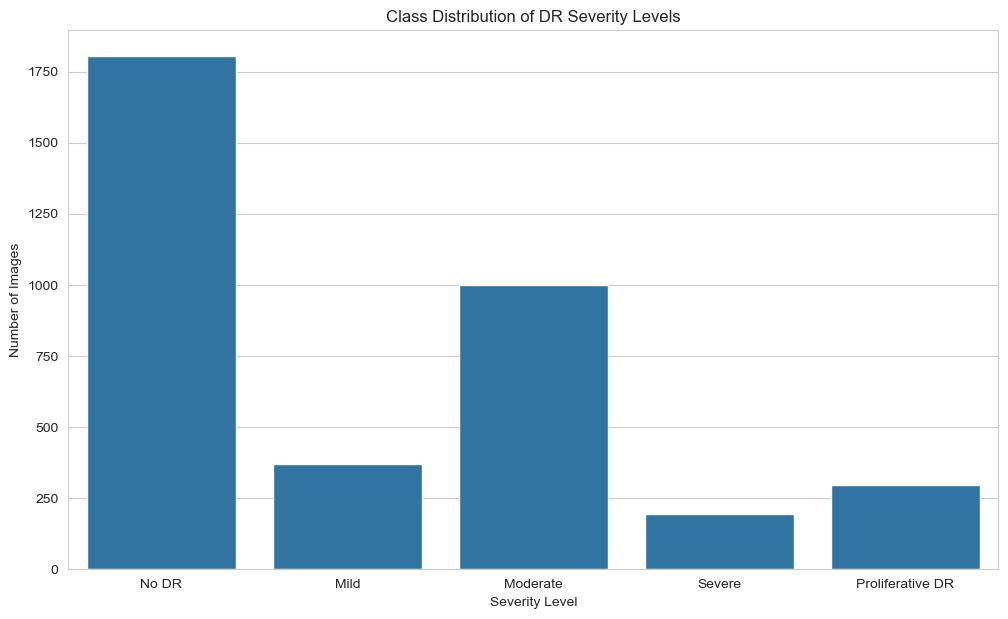

In [3]:
# [Fulfills plan goal: Check class distribution (imbalance issue)] 
print(df['diagnosis'].value_counts())

# Define class names for plotting
class_names = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative DR'
}
df['severity_level'] = df['diagnosis'].map(class_names)

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.countplot(x='severity_level', data=df, order=class_names.values())
plt.title('Class Distribution of DR Severity Levels')
plt.xlabel('Severity Level')
plt.ylabel('Number of Images')
plt.show()

Displaying sample images for each severity level...


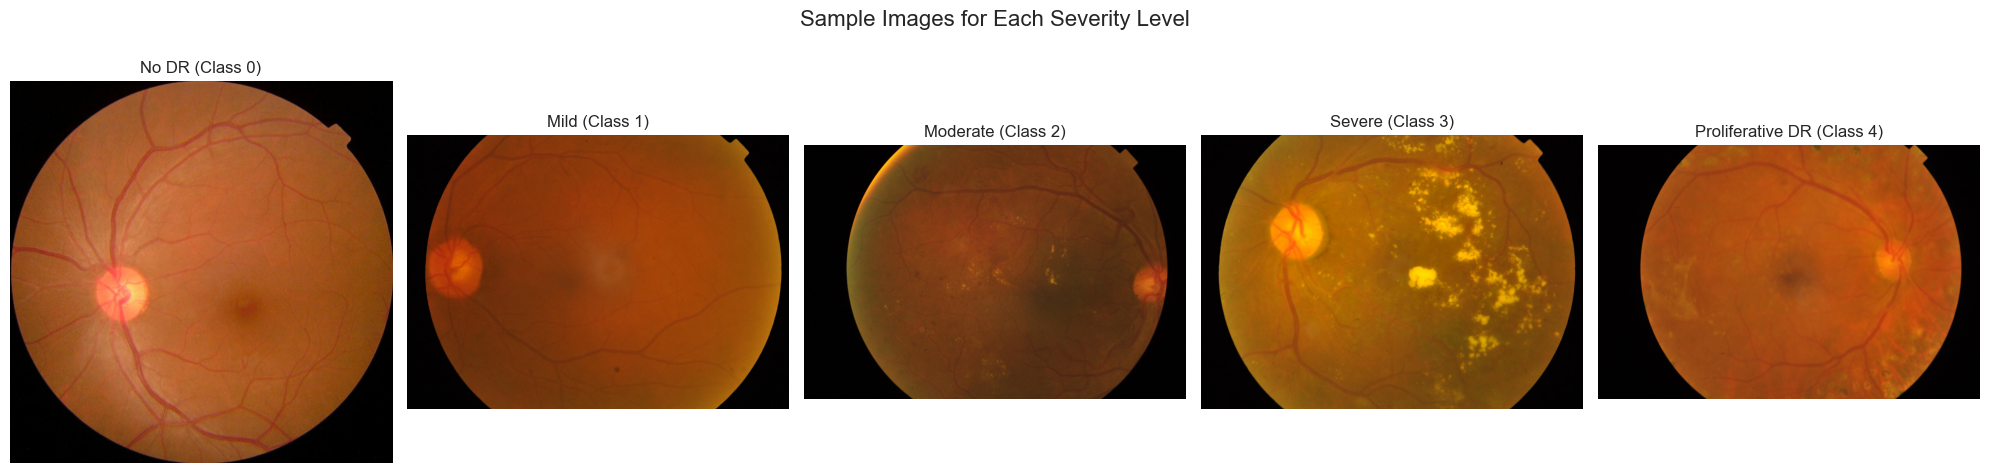

In [4]:
# [Fulfills plan goal: Sample images] [cite: 294]
print("Displaying sample images for each severity level...")

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Sample Images for Each Severity Level', fontsize=16)

for i, level_name in enumerate(class_names.values()):
    # Find the first image for this class
    sample_df = df[df['severity_level'] == level_name].iloc[0]
    img_id = sample_df['id_code']
    img_path = os.path.join(TRAIN_IMG_PATH, img_id + ".png")
    
    try:
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{level_name} (Class {sample_df['diagnosis']})")
        axes[i].axis('off')
    except FileNotFoundError:
        axes[i].set_title(f"Image not found for {level_name}")
        axes[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()